In [353]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mhnlib.utils as mhn_utils
import mhnlib.fit as mhn_fit
from math import log, sqrt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
torch.cuda.empty_cache()

## Load data

## Cells

In [4]:
torch.save({"cell_expressions": cell_expressions, "cell_lineages" : cell_lineages, "lineage_expressions": lineage_expressions, "lineage_to_row": lineage_to_row }, "paper_results/cells_data/cell_filtered_data.pt")
cells_mean = cell_expressions.mean(dim=0)
cells_rms = (cell_expressions-cells_mean).norm(dim=1).mean()
cells_data = (cell_expressions-cells_mean)/cells_rms
cells_gram = cells_data @ cells_data.T
K_cells = cells_gram.shape[0]
data_classes = torch.as_tensor([lineage_to_row[lineage] for lineage in cell_lineages], dtype=torch.long)

### Generate/load data

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
load_data = True
logit_noise_load = 3.0
betas = torch.logspace(-3, 3, steps=600)
logit_noise_stds = [1.0, 2.0, 3.0, 5.0, 10.0]
num_ics = K_cells*10
num_batches = max(1, num_ics//10000)
num_iterations = 10000
use_data_ic = True
if not load_data:
    for is_centered in [False, True]:
        for is_euclidean in [False, True]:
            if is_euclidean and is_centered:
                continue
            patterns_used = (
                           cells_data - cells_data.mean(dim=-2, keepdim=True)
                           if is_centered
                           else cells_data
                       )
            rms = patterns_used.norm(dim=-1, keepdim=True).mean()
            patterns_used = patterns_used/rms

            gram = patterns_used @ patterns_used.T
            diagonal = torch.diagonal(gram)

            if is_euclidean:
                biases = -0.5 * diagonal
            else:
                biases = torch.zeros_like(diagonal)

            for logit_noise_std in logit_noise_stds:

                if use_data_ic:
                    w_ics_indices = torch.randint(0, K_cells, (num_ics,), dtype=torch.long)
                    w_ics = torch.zeros(num_ics, K_cells)
                    w_ics[torch.arange(num_ics), w_ics_indices] = 1.0
                else:
                    w_ics = torch.randn(num_ics, K_cells)*logit_noise_std
                    w_ics = torch.softmax(w_ics, dim=-1)
                
                w_quenched = []
                w_annealed = []
                for batch_idx in range(num_batches):
                    batch_start = batch_idx * (num_ics // num_batches)
                    batch_end = (batch_idx + 1) * (num_ics // num_batches)
                    w_batch = w_ics[batch_start:batch_end]
                    w_quenched_batch = mhn_utils.dual_deterministic_dynamics(gram.to(device),
                                                                            biases.to(device),
                                                                            betas.to(device), w_batch.to(device), num_iterations=num_iterations, verbose=True).cpu().squeeze()


                    w_annealed_batch = mhn_utils.dual_deterministic_dynamics_annealing(gram.to(device),
                                                                                  biases.to(device), 
                                                                                  betas.to(device), w_batch.to(device), logit_noise_std=logit_noise_std, num_iterations=num_iterations, verbose=True).cpu().squeeze()
                    w_quenched.append(w_quenched_batch)
                    w_annealed.append(w_annealed_batch)
                w_quenched = torch.cat(w_quenched, dim=-2)
                w_annealed = torch.cat(w_annealed, dim=-2)
                torch.save({'w_quenched': w_quenched, 
                            'w_annealed': w_annealed, 
                            'patterns': patterns_used, 
                            'betas': betas,
                             'w_ics' : w_ics,
                            'ic_indices' : w_ics_indices if use_data_ic else None}, f'paper_results/cells_data/cells_weights_centered={is_centered}_euclidean={is_euclidean}_logit_noise_std={logit_noise_std}.pt')
else:
    euclidean_loaded_data = torch.load(f'paper_results/cells_data/cells_weights_centered=False_euclidean=True_logit_noise_std={logit_noise_load}.pt')
    centered_loaded_data = torch.load(f'paper_results/cells_data/cells_weights_centered=True_euclidean=False_logit_noise_std={logit_noise_load}.pt')
    raw_loaded_data = torch.load(f'paper_results/cells_data/cells_weights_centered=False_euclidean=False_logit_noise_std={logit_noise_load}.pt')
    #w_quenched_euclidean = euclidean_loaded_data['w_quenched']
    #w_annealed_euclidean = euclidean_loaded_data['w_annealed']
    #w_quenched_centered = centered_loaded_data['w_quenched']
    #w_annealed_centered = centered_loaded_data['w_annealed']
    #w_quenched_raw = raw_loaded_data['w_quenched']
    #w_annealed_raw = raw_loaded_data['w_annealed']

### Unique fixed points

In [6]:
is_centered = False
is_euclidean = True
reference_data = None
if is_centered:
    reference_data = centered_loaded_data
else:
    if is_euclidean:
        reference_data = euclidean_loaded_data
    else:
        reference_data = raw_loaded_data

w_quenched = reference_data['w_quenched']
w_annealed = reference_data['w_annealed']
betas = reference_data['betas']
w_ics = reference_data['w_ics']
ic_indices = reference_data['ic_indices']

In [7]:
patterns_used = (
    cells_data - cells_data.mean(dim=-2, keepdim=True)
    if is_centered
    else cells_data
)
rms = patterns_used.norm(dim=-1, keepdim=True).mean()
patterns_used = patterns_used/rms

gram = patterns_used @ patterns_used.T
diagonal = torch.diagonal(gram)
if is_euclidean:
    biases = -0.5 * diagonal
else:
    biases = torch.zeros_like(diagonal)

In [8]:
x_quenched = w_quenched @ patterns_used
x_annealed = w_annealed @ patterns_used

In [9]:
tolerance_threshold = 1e-4
num_quenched_fp = []
num_annealed_fp = []
x_quenched_fp = []
w_quenched_fp = []
x_annealed_fp = []  
w_annealed_fp = []
beta_indices = np.arange(0,x_quenched.shape[0])
pbar = tqdm(beta_indices)

for beta_idx in pbar:
    x_unique, x_unique_counts, x_labels = mhn_utils.group_by_distance(x_quenched[beta_idx], tolerance_threshold)
    w_unique = torch.zeros(x_unique.shape[0], w_quenched.shape[-1])
    w_unique.index_add_(0, x_labels, w_quenched[beta_idx])
    w_unique /= x_unique_counts[:, None]
    num_quenched_fp.append(x_unique.shape[0])
    x_quenched_fp.append(torch.as_tensor(x_unique))
    w_quenched_fp.append(w_unique)
    pbar.set_postfix({"Found clusters" : num_quenched_fp[-1] })
num_quenched_fp = torch.as_tensor(num_quenched_fp)

pbar = tqdm(beta_indices)
for beta_idx in pbar:
    x_unique, x_unique_counts, x_labels = mhn_utils.group_by_distance(x_annealed[beta_idx], tolerance_threshold)
    w_unique = torch.zeros(x_unique.shape[0], w_annealed.shape[-1])
    w_unique.index_add_(0, x_labels, w_annealed[beta_idx])
    w_unique /= x_unique_counts[:, None]
    num_annealed_fp.append(x_unique.shape[0])
    x_annealed_fp.append(torch.as_tensor(x_unique))
    w_annealed_fp.append(w_unique)
    pbar.set_postfix({"Found clusters" : num_annealed_fp[-1] })
num_annealed_fp = torch.as_tensor(num_annealed_fp)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

In [173]:
pca_patterns = PCA(n_components=5).fit(patterns_used)
patterns_proj = pca_patterns.transform(patterns_used)
for beta_idx in range(0, len(betas),1):
    fisher_matrices = mhn_utils.get_fisher_matrix(w_quenched_fp[beta_idx])
    jacobian_matrices = betas[beta_idx]* torch.einsum("...hi,...hk,...kj->...ij", patterns_used, fisher_matrices, patterns_used)
    jacobian_matrices -= torch.eye(jacobian_matrices.shape[-1])[None,...]
    j_vals, j_vecs = torch.linalg.eigh(jacobian_matrices)
    jm_proj = torch.einsum("ci,sim->scm", torch.as_tensor(pca_patterns.components_, dtype=j_vecs.dtype), j_vecs)
    fp_proj = torch.as_tensor(pca_patterns.transform(x_quenched_fp[beta_idx].numpy()), dtype=j_vecs.dtype)
    
    #plt.scatter(patterns_proj[:,0], patterns_proj[:,1], c='gray', label='Patterns', alpha=0.5)
    #plt.scatter(fp_proj[:,0], fp_proj[:,1], c='blue', label='Fixed Points')
    #for i in range(1):
    #    plt.quiver(fp_proj[:,0], fp_proj[:,1], jm_proj[:,0,-i-1], jm_proj[:,1,-i-1], angles='xy', scale_units='xy', scale=10)
#plt.show()
    #stab_quenched, proj_matr = mhn_utils.get_symmetric_stability_matrix(gram, w_quenched_fp[beta_idx], return_proj=True)
    #vals, vecs = torch.linalg.eigh(stab_quenched)    
    #proj_fp = pca_patterns.transform(x_quenched_fp[beta_idx].numpy())
    #proj_vecs = np.einsum("ck,skm->scm", pca_patterns.components_, vecs)
    #break

### Tree

In [176]:
from numba import njit
@njit(nogil=True)
def distance_tree(data_list, threshold : float):
    edges_from = []
    edges_to = []
    num_levels = len(data_list)
    for level in range(0, num_levels-1):
        num_elements_level = len(data_list[level])
        num_elements_next_level = len(data_list[level+1])
        for idx in range(0, num_elements_level):
            sq_norm_i = np.sum(data_list[level][idx]**2)
            for jdx in range(0, num_elements_next_level):
                sq_norm_j = np.sum(data_list[level+1][jdx]**2)
                dist_ij = sq_norm_i + sq_norm_j - 2*np.sum(data_list[level][idx]*data_list[level+1][jdx])
                if dist_ij <= threshold:
                    edges_from.append((level, idx))
                    edges_to.append((level+1, jdx))
    return np.array(edges_from), np.array(edges_to)

In [177]:
edgelist_from, edgelist_to = distance_tree([x.numpy() for x in x_quenched_fp], 1e-2)

In [178]:
import networkx as nx
G = nx.Graph()

G.add_edges_from(
    zip(map(tuple, edgelist_from), map(tuple, edgelist_to))
)

fp_connected_components = list(nx.connected_components(G))

In [312]:
num_labels = len(fp_connected_components)
labels = {}
for cc_index, cc_ in enumerate(fp_connected_components):
    cc = np.array(list(cc_))
    cc = cc[np.argsort(cc[:,0])]
    for el in cc:
        labels[(el[0],el[1])] = cc_index
import glasbey
import matplotlib.colors as mcolors

colors = np.array([
    mcolors.to_rgb(c)
    for c in glasbey.create_palette(palette_size=num_labels)
])

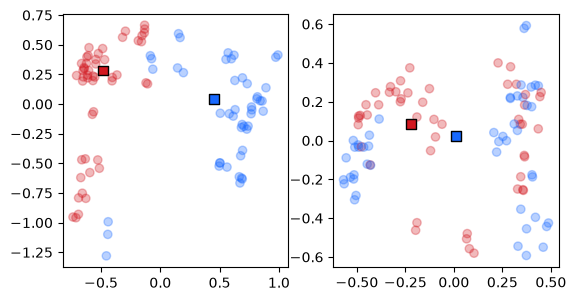

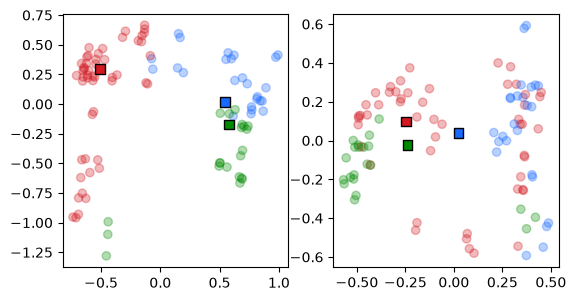

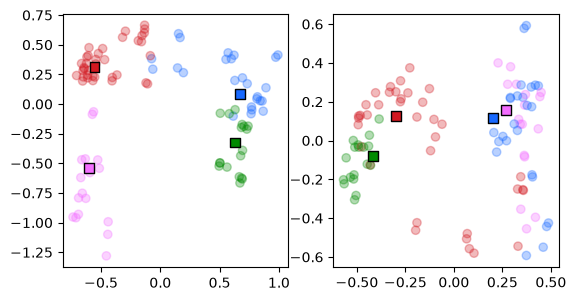

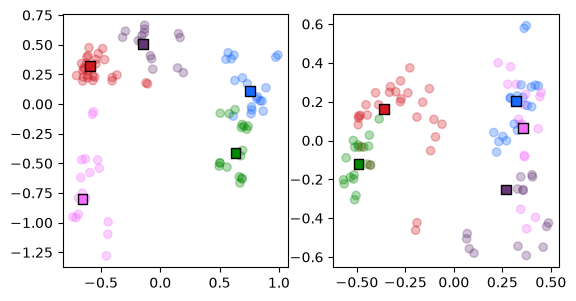

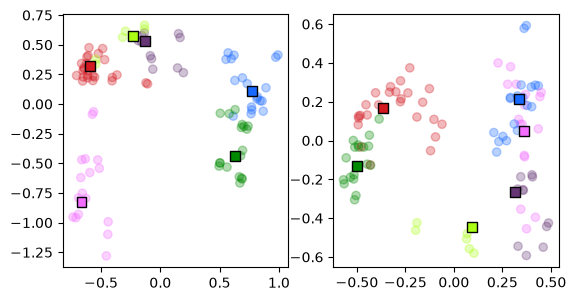

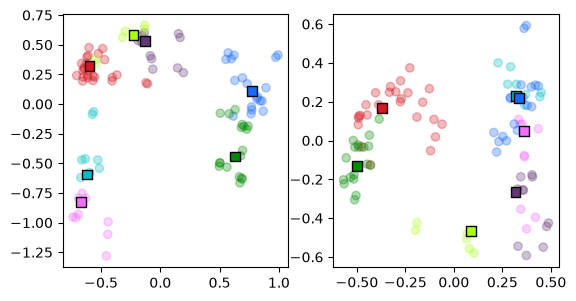

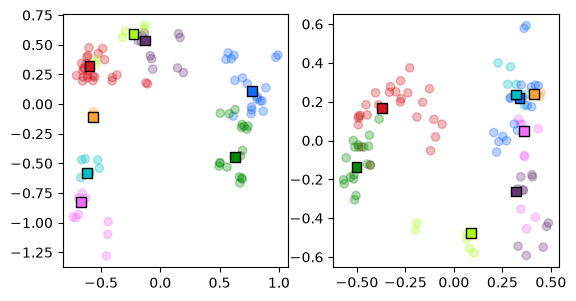

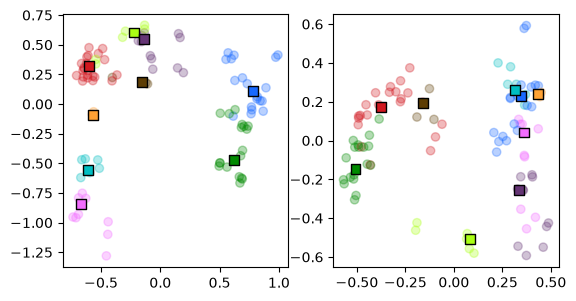

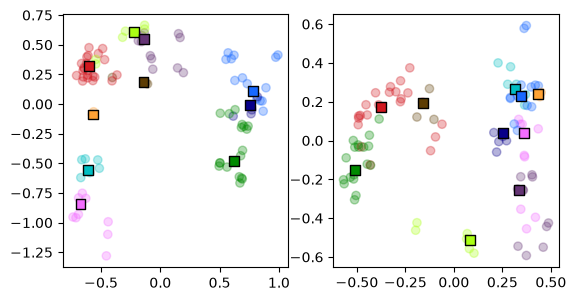

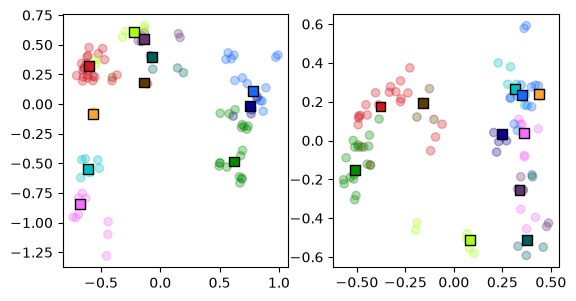

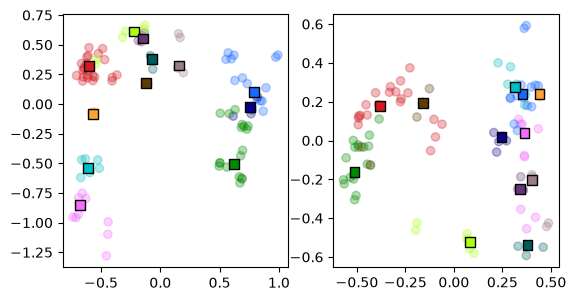

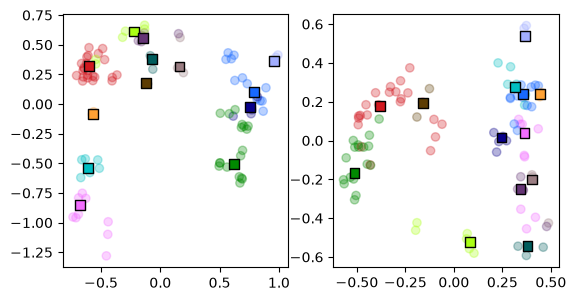

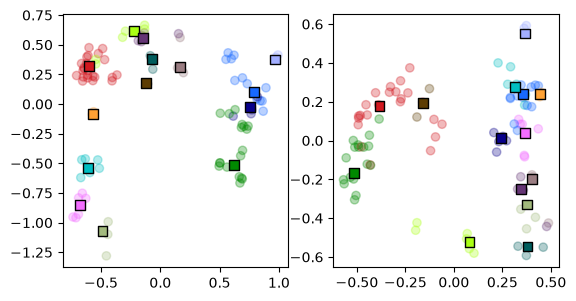

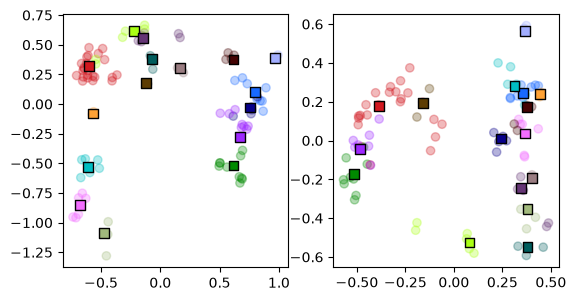

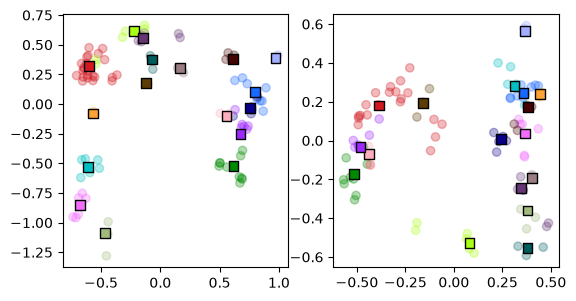

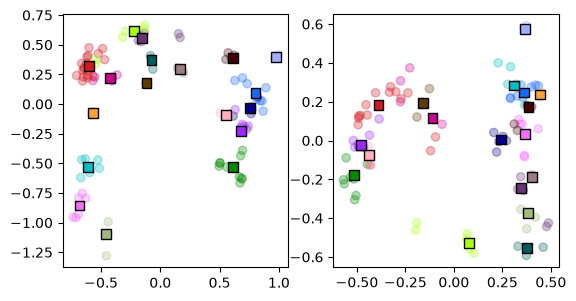

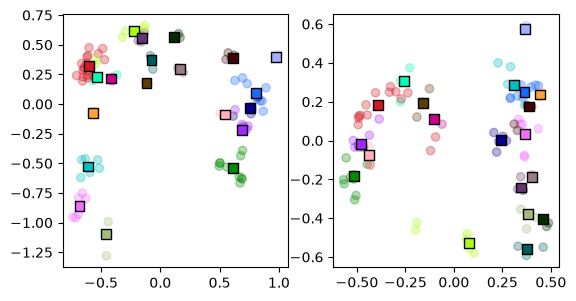

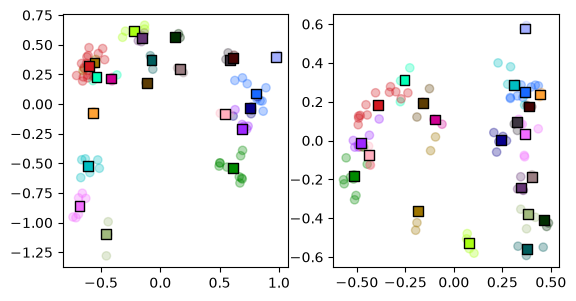

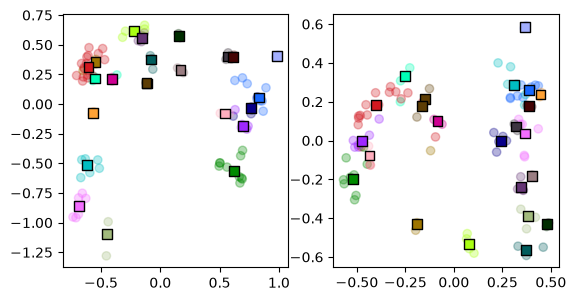

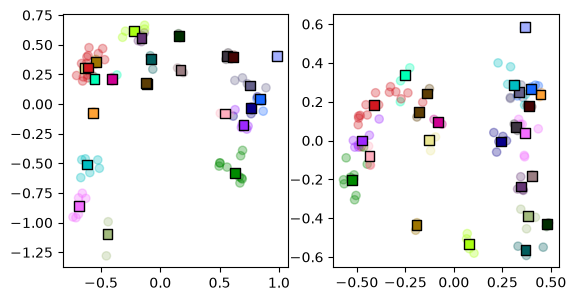

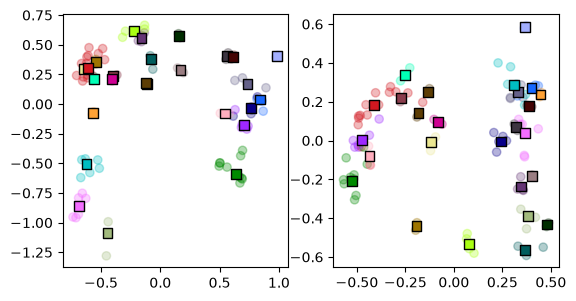

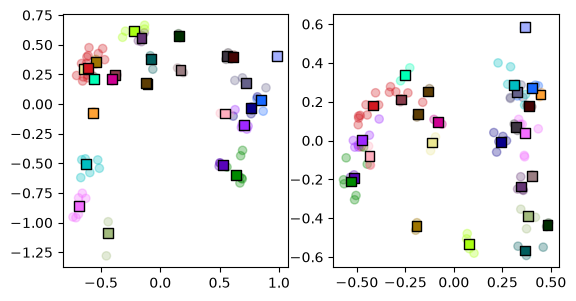

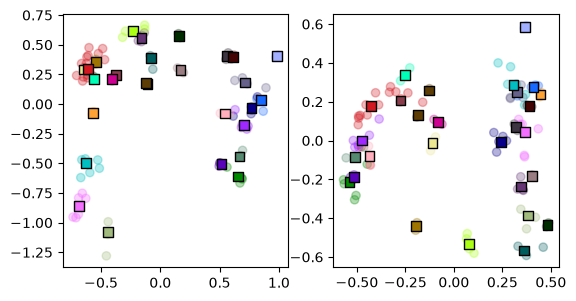

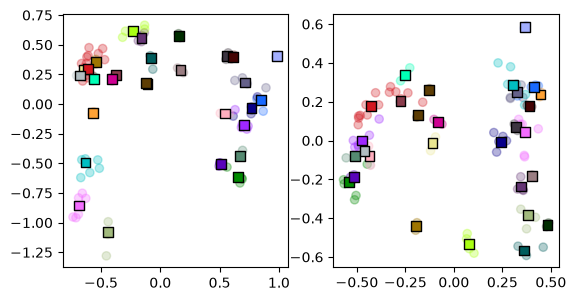

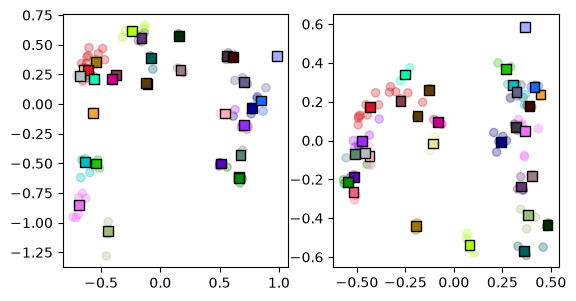

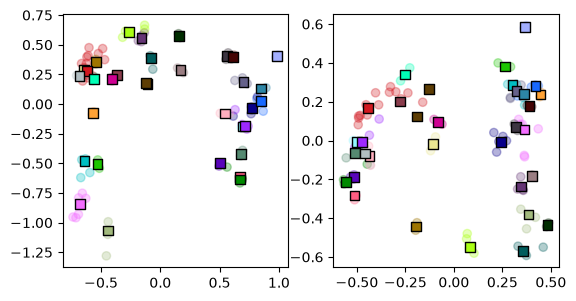

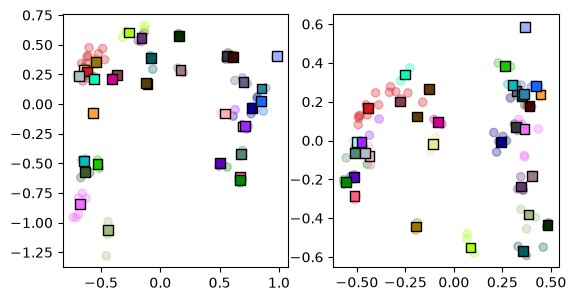

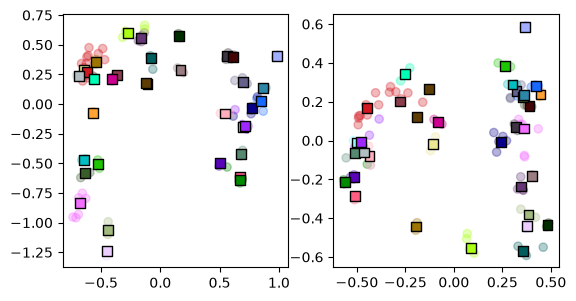

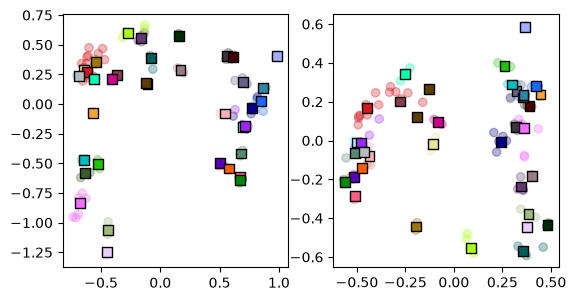

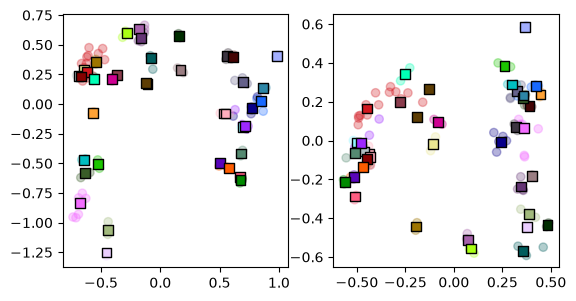

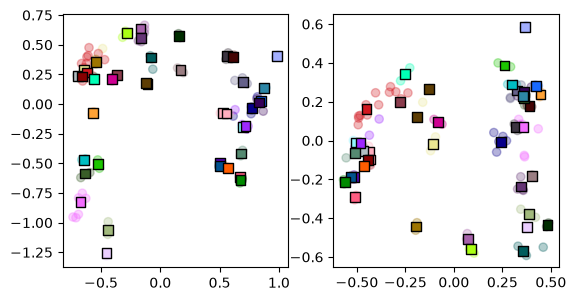

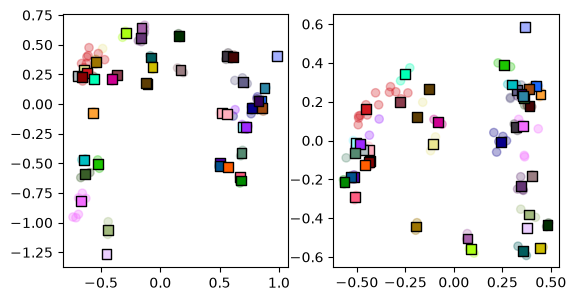

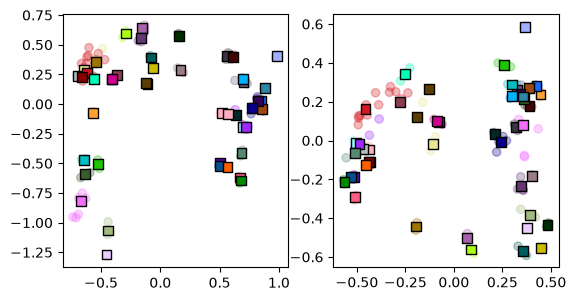

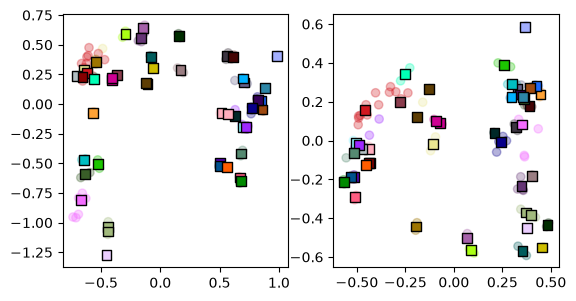

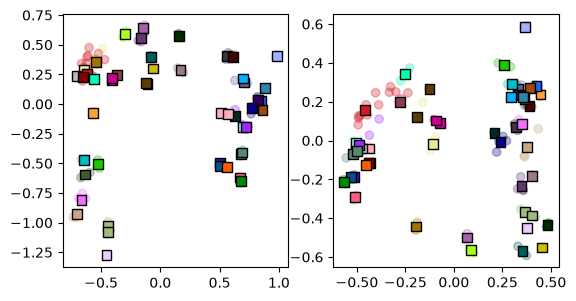

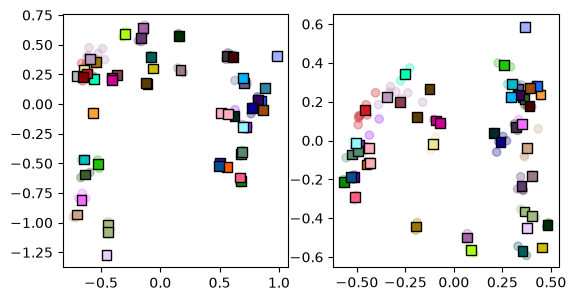

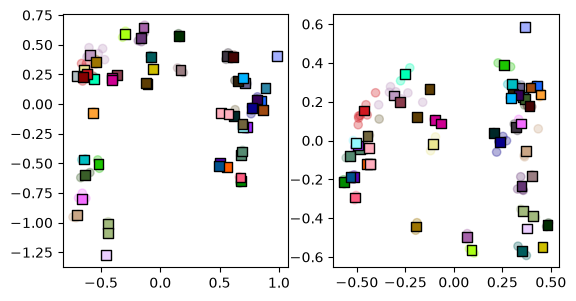

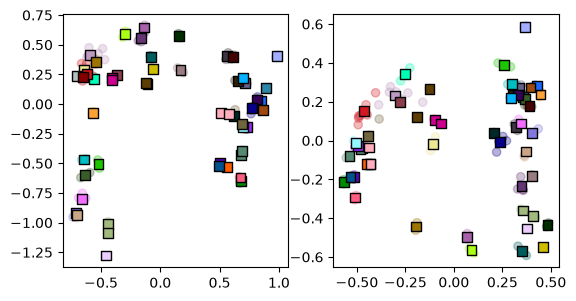

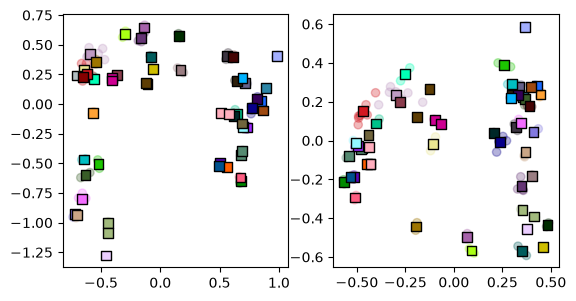

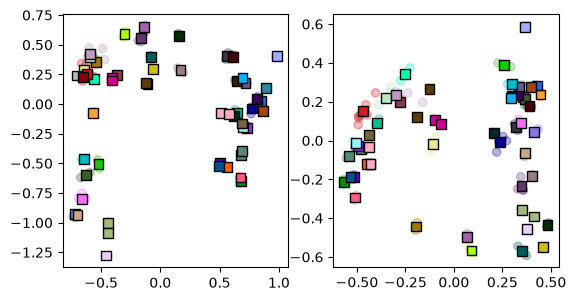

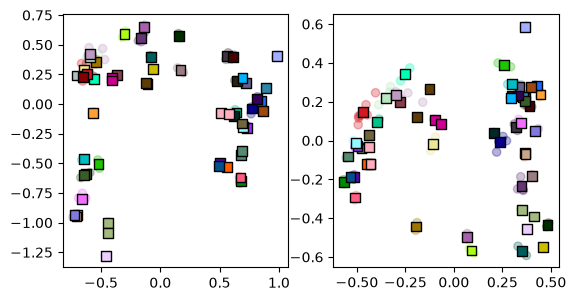

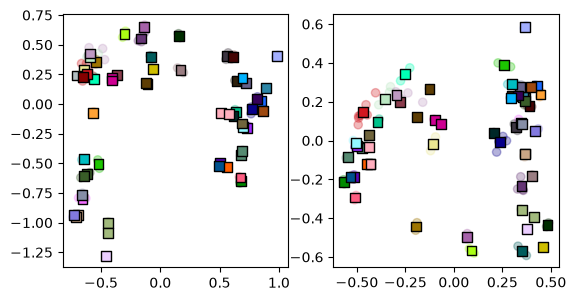

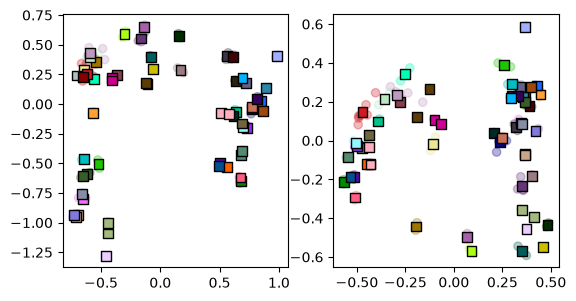

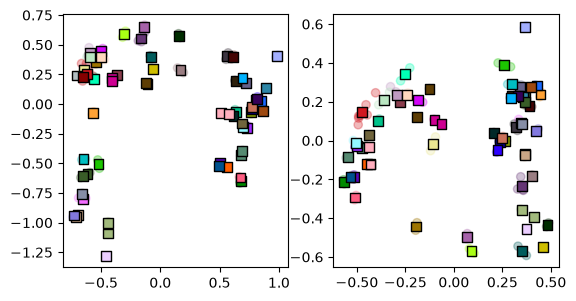

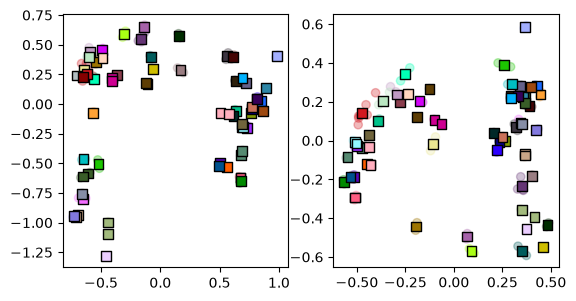

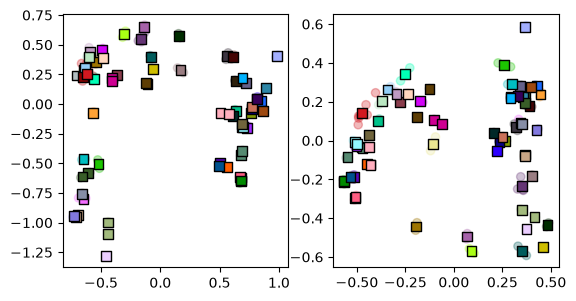

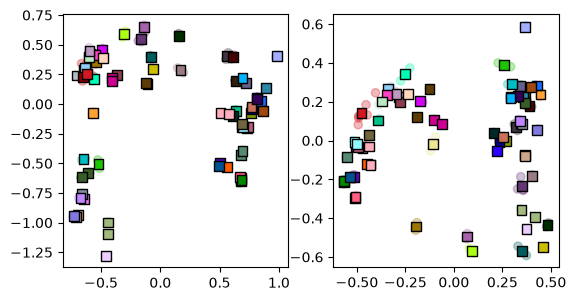

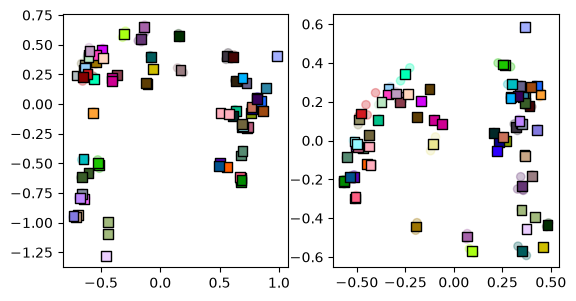

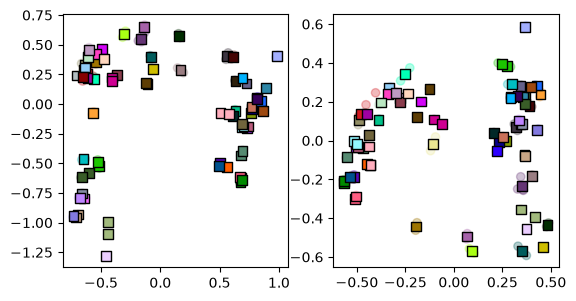

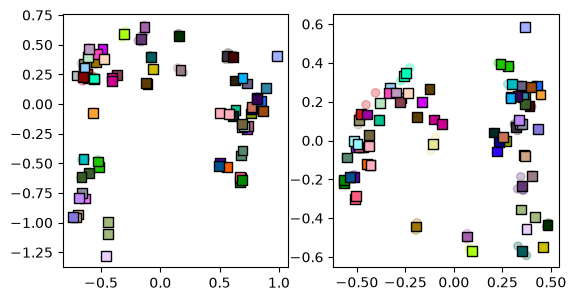

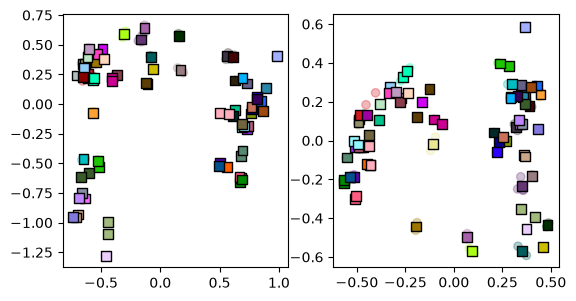

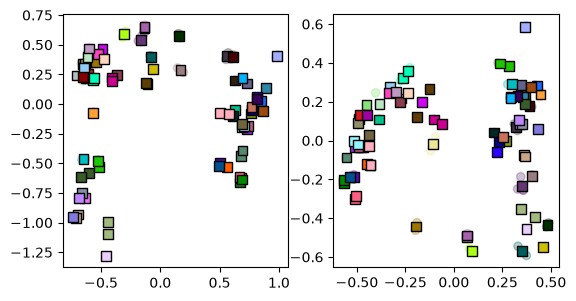

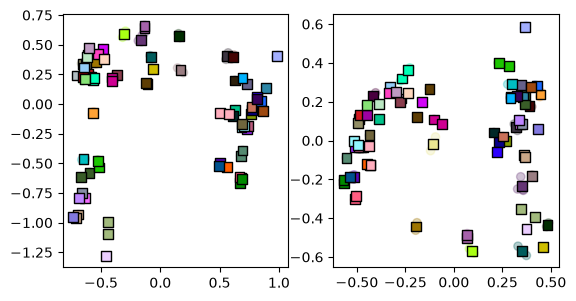

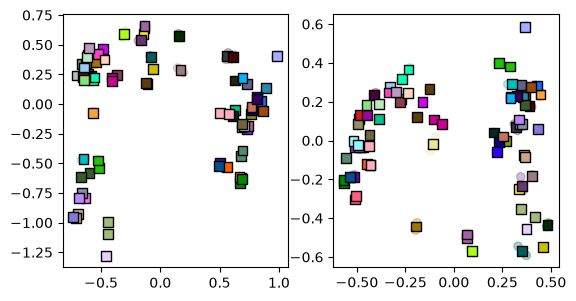

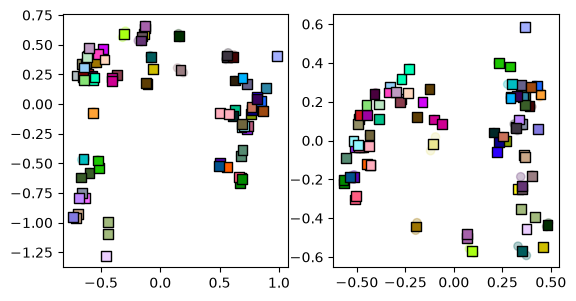

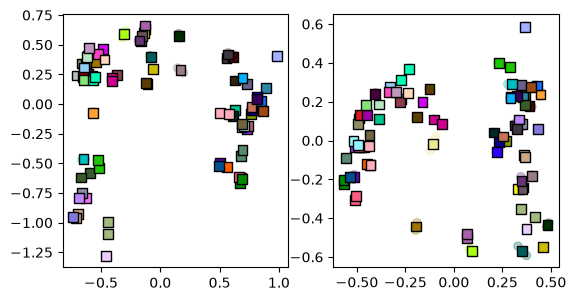

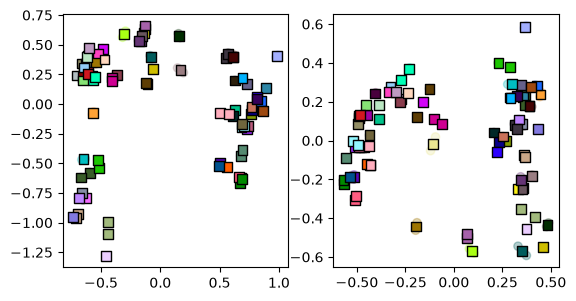

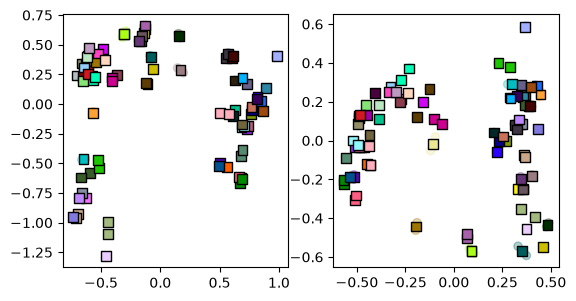

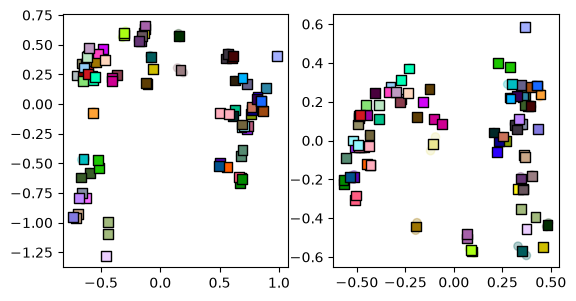

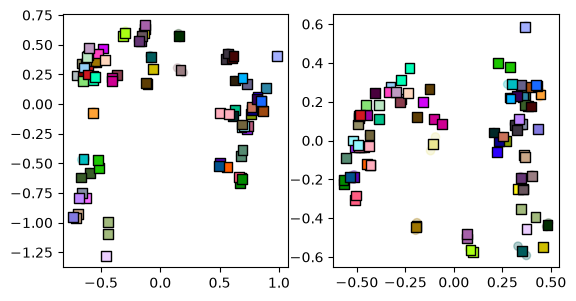

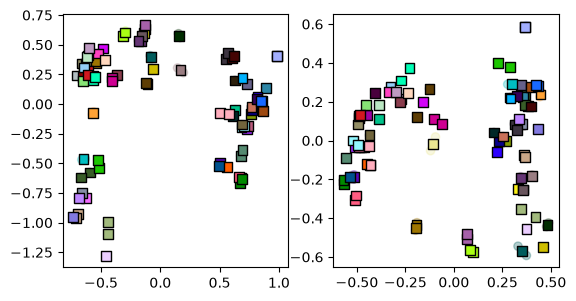

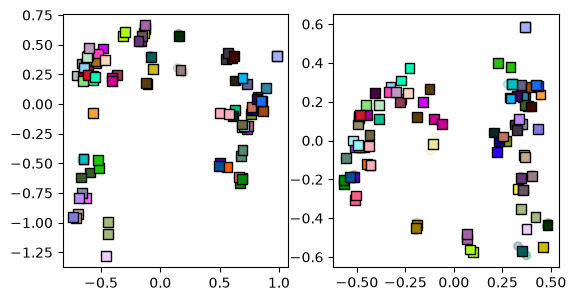

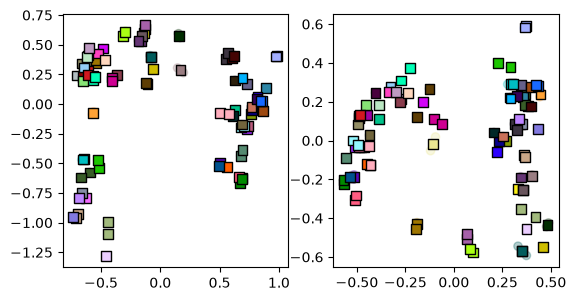

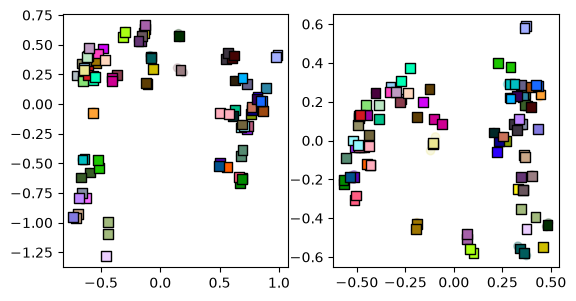

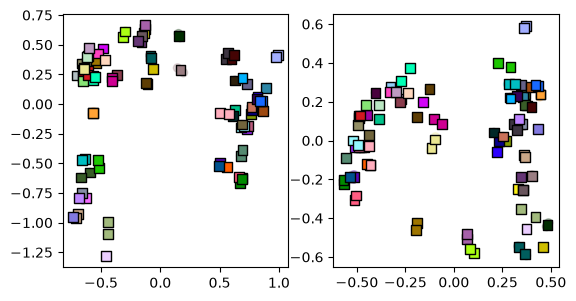

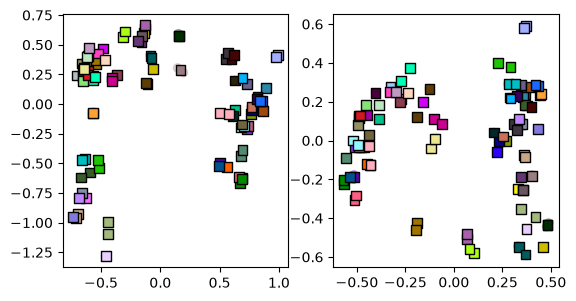

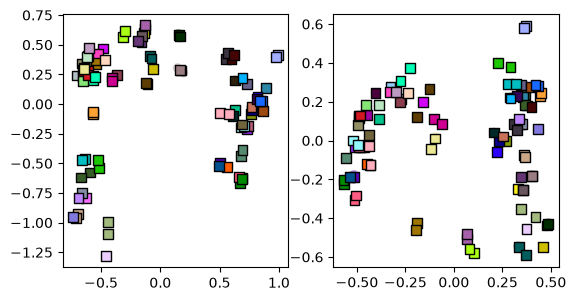

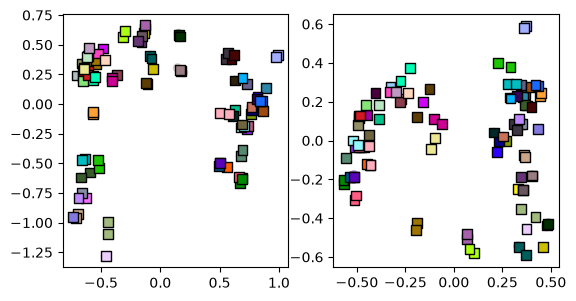

In [352]:
pca_patterns = PCA(n_components=5).fit(patterns_used)
patterns_proj = pca_patterns.transform(patterns_used)

for beta_idx in torch.argwhere(torch.diff(num_quenched_fp) > 0).flatten()+1:
    x_fp = x_quenched_fp[beta_idx]
    x_fp_proj = torch.as_tensor(pca_patterns.transform(x_fp))
    closest_fp_idx = ((patterns_used[:,None,:] - x_fp[None,:,:])**2).sum(dim=-1).argmin(dim=1)
    labels_fp = torch.as_tensor([ labels[(beta_idx.item(),idx)] for idx in range(len(x_fp))]) 
    labels_patterns = torch.as_tensor([ labels[(beta_idx.item(),idx.item())] for idx in closest_fp_idx])
    fig, axs = plt.subplots(ncols=2)
    axs[0].scatter(patterns_proj[:,0], patterns_proj[:,1],color=colors[labels_patterns], alpha=0.3)
    axs[0].scatter(x_fp_proj[:,0], x_fp_proj[:,1], color=colors[labels_fp], marker='s', s=50, edgecolors='black')
    axs[1].scatter(patterns_proj[:,2], patterns_proj[:,3],color=colors[labels_patterns], alpha=0.3)
    axs[1].scatter(x_fp_proj[:,2], x_fp_proj[:,3], color=colors[labels_fp], marker='s', s=50, edgecolors='black')
    axs[0].set_aspect('equal')
    axs[1].set_aspect('equal')
    plt.show()

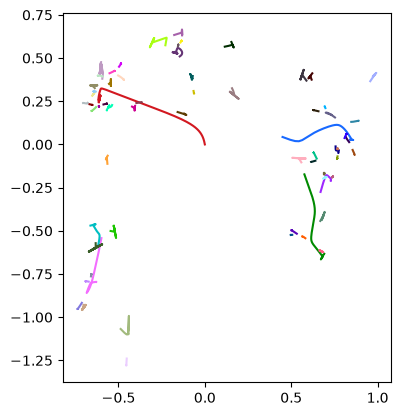

In [316]:
pca_patterns = PCA(n_components=5).fit(patterns_used)
patterns_proj = pca_patterns.transform(patterns_used)
for color, cc_ in zip(colors, fp_connected_components):
    cc = np.array(list(cc_))
    cc = cc[np.argsort(cc[:,0])]
    touched_betas = betas[cc[:,0]]
    touched_x_fps = torch.cat([ x_quenched_fp[beta_idx][idx][None,:]  for (beta_idx, idx) in cc], dim=0)
    touched_x_fps_proj = torch.as_tensor(pca_patterns.transform(touched_x_fps.numpy()))
    plt.plot(touched_x_fps_proj[:,0], touched_x_fps_proj[:,1], color=color)
plt.gca().set_aspect('equal')
plt.show()

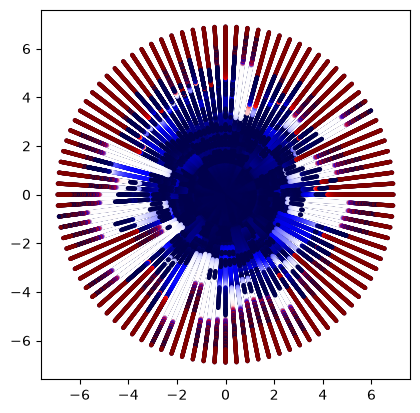

In [244]:
#sorting_by_class = torch.cat([ torch.argwhere(data_classes==c_label)  for c_label in torch.unique(data_classes)]).flatten()
angle_arg_plot = 2*np.pi*torch.arange(0,w_quenched.shape[-1])/w_quenched.shape[-1]
value_cutoff = 0.1/w_quenched.shape[-1]
for cc_ in fp_connected_components:
    cc = np.array(list(cc_))
    cc = cc[np.argsort(cc[:,0])]
    touched_betas = betas[cc[:,0]]
    touched_w_fps = torch.cat([ w_quenched_fp[beta_idx][idx][None,:]  for (beta_idx, idx) in cc], dim=0)
    touched_fps_entropies = mhn_utils.get_entropy(touched_w_fps)
    plot_mask = touched_w_fps > value_cutoff
    plot_mask = plot_mask.flatten()
    plt.scatter( (touched_betas.log()[:,None]*torch.cos(angle_arg_plot)[None,:]).flatten()[plot_mask] ,
                (touched_betas.log()[:,None]*torch.sin(angle_arg_plot)[None,:]).flatten()[plot_mask],
                c = touched_w_fps.flatten()[plot_mask], vmin=0.0, vmax=1.0, s=4, cmap='seismic')
plt.gca().set_aspect('equal')
plt.show()

### Stability analysis

In [ ]:
entropy = mhn_utils.get_entropy(w_quenched)
mean_entropy = entropy.mean(dim=1)
entropy_quantiles = torch.quantile(entropy, torch.as_tensor([0.1, 0.5, 0.9]), dim=1)
plt.plot(betas,num_clusters, color='black')
plt.plot(betas, torch.exp(np.log(K_cells) - entropy_quantiles[0]), color='blue')
plt.plot(betas, torch.exp(np.log(K_cells) - entropy_quantiles[1]), color='purple')
plt.plot(betas, torch.exp(np.log(K_cells) - entropy_quantiles[2]), color='red')

In [ ]:
from numba import njit
@njit(nogil=True)
def distance_tree(data_list, threshold : float):
    edges_from = []
    edges_to = []
    num_levels = len(data_list)
    for level in range(0, num_levels-1):
        num_elements_level = len(data_list[level])
        num_elements_next_level = len(data_list[level+1])
        for idx in range(0, num_elements_level):
            sq_norm_i = np.sum(data_list[level][idx]**2)
            for jdx in range(0, num_elements_next_level):
                sq_norm_j = np.sum(data_list[level+1][jdx]**2)
                dist_ij = sq_norm_i + sq_norm_j - 2*np.sum(data_list[level][idx]*data_list[level+1][jdx])
                if dist_ij <= threshold:
                    edges_from.append((level, idx))
                    edges_to.append((level+1, jdx))
    return np.array(edges_from), np.array(edges_to)

In [ ]:
edgelist_from, edgelist_to = distance_tree(clusters, 1e-1)

In [ ]:
import networkx as nx
G = nx.Graph()

G.add_edges_from(
    zip(map(tuple, edgelist_from), map(tuple, edgelist_to))
)

fp_connected_components = list(nx.connected_components(G))

In [ ]:
import matplotlib.cm as cm
from pathlib import Path
pca_patterns = PCA(n_components=5).fit(patterns_used)
patterns_proj = pca_patterns.transform(patterns_used)

In [ ]:
for component in fp_connected_components:
    sub = G.subgraph(component)
    root_sub = min(list(sub.nodes()), key= lambda a:a[0]) 
    dfs_order = list(nx.dfs_preorder_nodes(sub, root_sub))
    touched_points = np.array([ clusters[node[0]][node[1]] for node in dfs_order])
    touched_points_proj = pca_patterns.transform(touched_points)
    plt.plot(touched_points_proj[:,0], touched_points_proj[:,1])
plt.show()

In [ ]:
import scipy.sparse as sparse
from scipy.sparse.csgraph import connected_components
packed_mapper = { }
counter = 0
for beta_idx, data in enumerate(clusters):
    for idx in range(data.shape[0]):
        packed_mapper[counter] = (beta_idx, idx)
        counter += 1
inverse_mapper = { b : a for a,b in packed_mapper.items()}
packed_clusters = np.concatenate(clusters, axis=0)
packed_clusters_sqnorms = (packed_clusters**2).sum(axis=1)
clusters_beta_indices = np.concatenate([ np.ones(len(clusters[idx]), dtype=np.int64)*idx for idx in range(0, len(clusters))])
betas_clusters = betas.numpy()[clusters_beta_indices]
distances = packed_clusters_sqnorms[:,None] + packed_clusters_sqnorms[None,:] - 2*packed_clusters @ packed_clusters.T
valid_indices = np.argwhere(distances <= 100*tolerance_threshold)
keep_mask = clusters_beta_indices[valid_indices[:,0]]+1 == clusters_beta_indices[valid_indices[:,1]]
valid_indices = valid_indices[keep_mask]
num_labels, labels = connected_components(sparse.coo_array(
    (np.ones(len(valid_indices)), (valid_indices[:,0], valid_indices[:,1])),
    shape=(len(packed_clusters), len(packed_clusters))).tocsr(), directed=True)
valid_indices_from = np.array([ packed_mapper[pdx]  for pdx in valid_indices[:,0]])
valid_indices_to = np.array([ packed_mapper[pdx]  for pdx in valid_indices[:,1]])

In [ ]:
import matplotlib.cm as cm
from pathlib import Path
pca_patterns = PCA(n_components=5).fit(patterns_used)
patterns_proj = pca_patterns.transform(patterns_used)
packed_clusters_proj = pca_patterns.transform(packed_clusters)
save_path = Path("paper_results/cells_data/plots/sequence/")
save_path.mkdir(parents=True, exist_ok=True)
do_scatter = False
for beta_idx in range(0, len(betas)):
    for label in range(0, num_labels):
        main_mask = labels == label
        main_mask *= betas_clusters <= betas[beta_idx].item()
        valid_indices_label = np.argwhere(main_mask).flatten()
        mask = np.isin(valid_indices[:,0], valid_indices_label)
        if mask.sum() <= 2:
            continue
        colors = (np.log10(betas_clusters[main_mask]) - betas[0].log10().item())/(betas[-1].log10()-betas[0].log10()).item()
        plt.scatter(patterns_proj[:,0], patterns_proj[:,1],s=10, color='black', marker='*')
        if do_scatter:
            plt.scatter(packed_clusters_proj[main_mask,0], packed_clusters_proj[main_mask,1],
                        c=cm.jet(colors ), s=10)
        else:
            plt.plot(packed_clusters_proj[main_mask,0], packed_clusters_proj[main_mask,1])
        #plt.quiver(packed_clusters_proj[valid_indices[mask,0],0], packed_clusters_proj[valid_indices[mask,0],1],
        #           packed_clusters_proj[valid_indices[mask,1],0] - packed_clusters_proj[valid_indices[mask,0],0],
        #           packed_clusters_proj[valid_indices[mask,1],1] - packed_clusters_proj[valid_indices[mask,0],1],
        #          angles='xy',
        #           scale=1,
        #           scale_units='xy'
        #          )
        #plt.quiver(valid_indices_from[mask,0], valid_indices_from[mask,1], 
        #       valid_indices_to[mask,0] - valid_indices_from[mask,0] 
        #       , valid_indices_to[mask,1] - valid_indices_from[mask,1] )
    plt.savefig(save_path / f"{beta_idx}.png")
    plt.close()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def _clip_polygon_halfplane(poly, a, b, tol=1e-10):
    """
    Clip a convex polygon to the half-plane

        a @ x <= b

    poly: (m, 2) array of polygon vertices
    """
    if poly is None or len(poly) == 0:
        return None

    def inside(p):
        return np.dot(a, p) <= b + tol

    def intersection(p1, p2):
        d = p2 - p1
        denom = np.dot(a, d)

        if abs(denom) < tol:
            return p1

        t = (b - np.dot(a, p1)) / denom
        return p1 + t * d

    out = []

    for k in range(len(poly)):
        p1 = poly[k]
        p2 = poly[(k + 1) % len(poly)]

        in1 = inside(p1)
        in2 = inside(p2)

        if in1 and in2:
            out.append(p2)

        elif in1 and not in2:
            out.append(intersection(p1, p2))

        elif not in1 and in2:
            out.append(intersection(p1, p2))
            out.append(p2)

    if len(out) < 3:
        return None

    return np.asarray(out)


def pca_power_diagram(X, pad=0.15, plot=True):
    """
    Restrict the Euclidean Voronoi diagram of points X in R^N
    to their 2D PCA plane.

    This produces a 2D power diagram.

    Parameters
    ----------
    X : array, shape (n_samples, n_features)
    pad : float
        Padding around PCA points for the plotting bounding box.
    plot : bool

    Returns
    -------
    dict with:
        pca
        sites        : PC1/PC2 coordinates
        residual_sq  : squared distance from each original point
                       to the PCA plane
        cells        : polygon vertices for each power cell
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("X must be a 2D array")

    if np.isnan(X).any():
        raise ValueError("X contains NaNs")

    # PCA
    pca = PCA(n_components=2)
    Z = pca.fit_transform(X)   # 2D projected sites

    # Reconstruction of X from the first two PCs
    X_hat = pca.inverse_transform(Z)

    # r_i^2: squared perpendicular distance to PCA plane
    residual_sq = np.sum((X - X_hat) ** 2, axis=1)

    n = len(Z)

    # Bounding box
    xmin, ymin = Z.min(axis=0)
    xmax, ymax = Z.max(axis=0)

    dx = xmax - xmin
    dy = ymax - ymin

    if dx == 0:
        dx = 1
    if dy == 0:
        dy = 1

    xmin -= pad * dx
    xmax += pad * dx
    ymin -= pad * dy
    ymax += pad * dy

    bbox = np.array([
        [xmin, ymin],
        [xmax, ymin],
        [xmax, ymax],
        [xmin, ymax],
    ])

    cells = []

    for i in range(n):
        poly = bbox.copy()

        for j in range(n):
            if i == j:
                continue

            # Cell i satisfies:
            #
            # ||y - Zi||^2 + r_i^2
            # <=
            # ||y - Zj||^2 + r_j^2
            #
            # which becomes:
            #
            # 2 (Zj - Zi) @ y
            # <= ||Zj||^2 + r_j^2 - ||Zi||^2 - r_i^2

            a = 2 * (Z[j] - Z[i])

            b = (
                np.dot(Z[j], Z[j])
                + residual_sq[j]
                - np.dot(Z[i], Z[i])
                - residual_sq[i]
            )

            poly = _clip_polygon_halfplane(poly, a, b)

            if poly is None:
                break

        cells.append(poly)

    if plot:
        fig, ax = plt.subplots(figsize=(8, 8))

        for poly in cells:
            if poly is not None:
                closed = np.vstack([poly, poly[0]])
                ax.plot(closed[:, 0], closed[:, 1], linewidth=1)

        ax.scatter(Z[:, 0], Z[:, 1])

        for i, (x, y) in enumerate(Z):
            ax.annotate(str(i), (x, y), xytext=(3, 3),
                        textcoords="offset points")

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title("Power diagram on PCA plane")
        ax.set_aspect("equal")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

        plt.show()

    return {
        "pca": pca,
        "sites": Z,
        "residual_sq": residual_sq,
        "cells": cells,
    }

### Exploration

In [ ]:


def get_all_clusters(data_coll, dists_coll, min_num_clusters, max_num_clusters):
    all_clusters = []
    for (data, dists) in zip(data_coll, dists_coll):
        best_score = -1
        best_num_clusters = None
        best_labels = None
        for num_clusters in range(min_num_clusters, min(max_num_clusters, data.shape[0]-1) + 1):
            model = AgglomerativeClustering(
                n_clusters=num_clusters,
                metric="precomputed",
                linkage="average",
            )
            labels = model.fit_predict(dists.cpu().numpy())
            score = silhouette_score(dists.cpu().numpy(), labels, metric="precomputed")
            if score > best_score:
                best_score = score
                best_num_clusters = num_clusters
                best_labels = labels
        unique_labels, counts = np.unique(best_labels, return_counts=True)
        clusters = []
        for label, count in zip(unique_labels, counts):
            clusters.append( data[best_labels == label].mean(dim=0) )
        clusters = torch.stack(clusters, dim=0)
        all_clusters.append(clusters)
    return all_clusters

In [ ]:
lineages_stab_unif = mhn_utils.get_symmetric_stability_matrix(lineages_patterns_gram,torch.ones(K)/K, return_proj=False )
lineages_beta_c_unif = 1.0/torch.linalg.eigvalsh(lineages_stab_unif)[-1]

fp_nodes = {0 : (torch.ones(K)/K, lineages_beta_c_unif) }
fp_tree = {0 : []}
fp_levels = {0 : [0]}

In [ ]:
delta_betas = torch.logspace(-2, -1, steps=10)
num_ics = 3000
logit_noise_ics = 0.1
max_num_bifurcations = 3
for level in range(max_num_bifurcations):
    print(f"Level {level}: {len(fp_levels[level])} nodes")
    for node_idx in fp_levels[level]:
        w_node, beta_c_node = fp_nodes[node_idx]
        betas_next = beta_c_node + delta_betas
        w_next_ics = torch.softmax(logit_noise_ics*torch.randn(num_ics, K) + w_node.log()[None, :] , dim=1)
        w_next = mhn_utils.dual_deterministic_dynamics(lineages_patterns_gram,
                                                        torch.zeros(K),
                                                          betas_next, 
                                                          w_next_ics,
                                                            num_iterations=10000, verbose=True).squeeze()
        

        b_dists = -(torch.einsum("bsk,brk->bsr", w_next.sqrt(), w_next.sqrt()).log())
        b_dists = b_dists.clamp(min=0.0)
        all_clusters = get_all_clusters(w_next, b_dists, min_num_clusters=2, max_num_clusters=K)
        all_clusters = torch.cat(all_clusters, dim=0)
        all_clusters = all_clusters.view(-1, all_clusters.shape[-1])
        all_b_dists = -(torch.einsum("rk,sk->rs", all_clusters.sqrt(), all_clusters.sqrt()).log())
        all_b_dists = all_b_dists.clamp(min=0.0)
        final_clusters = get_all_clusters(all_clusters.unsqueeze(0), all_b_dists.unsqueeze(0), min_num_clusters=2, max_num_clusters=K)[0]

        final_clusters_stab_matr = mhn_utils.get_symmetric_stability_matrix(lineages_patterns_gram, final_clusters, return_proj=False)
        final_clusters_beta_c = 1.0/torch.linalg.eigvalsh(final_clusters_stab_matr)[:,-1]

        current_max_node_idx = max(fp_nodes.keys())
        for cluster_idx in range(final_clusters.shape[0]):
            print(f"Adding node {current_max_node_idx + 1 + cluster_idx} with beta_c = {final_clusters_beta_c[cluster_idx]:.4f} and entropy = {mhn_utils.get_entropy(final_clusters[cluster_idx]):.4f}")
            new_node_idx = current_max_node_idx + 1 + cluster_idx
            fp_nodes[new_node_idx] = (final_clusters[cluster_idx], final_clusters_beta_c[cluster_idx])
            fp_tree[node_idx].append(new_node_idx)
            if level+1 not in fp_levels:
                fp_levels[level+1] = []
            fp_levels[level+1].append(new_node_idx)
            fp_tree[new_node_idx] = []
            fp_tree[node_idx].append(new_node_idx)

In [ ]:

for level, nodes in fp_levels.items():
    all_w_level = torch.stack([fp_nodes[node_idx][0] for node_idx in nodes], dim=0)
    all_entropies_level = mhn_utils.get_entropy(all_w_level)
    all_beta_c_level = torch.stack([fp_nodes[node_idx][1] for node_idx in nodes], dim=0)
    #plt.scatter(all_beta_c_level, all_entropies_level/log(K))
    plt.scatter(all_beta_c_level, torch.ones(len(all_beta_c_level))*level)
    for node_idx in nodes:
        for child_idx in fp_tree[node_idx]:
            plt.plot([fp_nodes[node_idx][1], fp_nodes[child_idx][1]], [level, level+1], color='gray', alpha=0.5)
plt.show()

## Other

In [ ]:
beta0 = 0.0
delta_betas = torch.logspace(-1, 2, steps=100)
betas = beta0 + delta_betas
fisher = mhn_utils.get_fisher_matrix(torch.ones(K)/K)
a_matrix = betas[:, None, None] * (fisher @ lineages_patterns_gram)[None,:,:] - torch.eye(K)[None,:,:]
b_vec = -delta_betas[:,None] * (fisher @ lineages_patterns_gram @ torch.ones(K)/K)[None,:]
delta_w = torch.linalg.solve(a_matrix, b_vec)
w = torch.ones(K)/K + delta_w

In [ ]:
affinity = torch.diag(lineages_patterns_gram)[:,None] +  torch.diag(lineages_patterns_gram)[None,:] - 2*lineages_patterns_gram
beta_aff = 0.1
aff_weights = torch.exp(-beta_aff*affinity)
laplacian = torch.diag(aff_weights.sum(dim=1)) - aff_weights
lapl_vals, lapl_vecs = torch.linalg.eigh(laplacian)

In [ ]:
plt.imshow(lapl_vecs[:,:]**2, vmin=0, vmax=1)
plt.colorbar()
plt.show()

In [ ]:
clusters, log_biases, beta_hist = mhn_fit(
    data=cells_data,
    num_clusters=11,
    log_beta_0=0.0,
    fit_bias=True,
    batch_size=64,
    learning_rate=0.01,
    num_epochs=1000,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    cov_estimator_num_batches=5
)

In [ ]:
plt.plot(beta_hist)

In [ ]:
plt.imshow(clusters @ lineages_data.T, vmin=-1.0, vmax=1.0, cmap='coolwarm')
plt.gca().set_xticks(range(K), lineage_ids, rotation=90)
plt.gca().set_yticks(range(clusters.shape[0]), [f"Cluster {i}" for i in range(clusters.shape[0])])
plt.colorbar()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from scipy.spatial import Voronoi, voronoi_plot_2d
pca_on_data = PCA(n_components=5).fit(cells_data.numpy())
components_to_show = [2,3]
data_pca = pca_on_data.transform(cells_data)
clusters_pca = pca_on_data.transform(clusters)
lineages_pca = pca_on_data.transform(lineages_data)
voronoi_plot_2d(Voronoi(clusters_pca[:, components_to_show]), show_vertices=False, line_colors='orange', line_width=2, line_alpha=0.6, point_size=2)
plt.scatter(data_pca[:,components_to_show[0]], data_pca[:,components_to_show[1]], alpha=0.5, c=data_classes, cmap='tab20')
plt.scatter(clusters_pca[:,components_to_show[0]], clusters_pca[:,components_to_show[1]], c=torch.softmax(log_biases, dim=0).numpy(), s=50, edgecolor='k')
plt.scatter(lineages_pca[:,components_to_show[0]], lineages_pca[:,components_to_show[1]], c='black', s=50, edgecolor='k', marker='*')
plt.xlim(data_pca[:,components_to_show[0]].min(), data_pca[:,components_to_show[0]].max())
plt.ylim(data_pca[:,components_to_show[1]].min(), data_pca[:,components_to_show[1]].max())
plt.show()

### Fixed Points Tree

In [ ]:
delta_betas = torch.logspace(-2, -1, steps=5)
betas_next = beta_c_unif + delta_betas
num_ics = 1000
logit_noise_ics = 0.1
w_next_ics = torch.softmax(logit_noise_ics * torch.randn(num_ics, K), dim=1)
w_next = mhn_utils.dual_deterministic_dynamics(gram, bias, betas_next, w_next_ics, num_iterations=1000, verbose=True).squeeze()

In [ ]:
for beta, beta_idx, in zip(betas_next, range(len(betas_next))):
    sns.clustermap(w_next[beta_idx] @ w_next[beta_idx].T)
    plt.show()